In [5]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter

import matplotlib.pyplot as plt


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/trigger_study/wk22/standardized_flow/calibration_config.yaml')
lts = LongTraceSimulator(config)
ng = NoiseGenerator(config)

In [6]:
noise_trace = ng.generate_noise(5_000_000)
noise_trace32 = noise_trace.astype(np.float32)

In [7]:
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
fs = 3906250
noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
WORKER_OF_SUB = OptimumFilter(sub_template, noise_psd, fs)

In [8]:
amps, _ = WORKER_OF_SUB.sliding_fit(noise_trace32, hop=1, reanchor_every=None, chisq_mode="none")

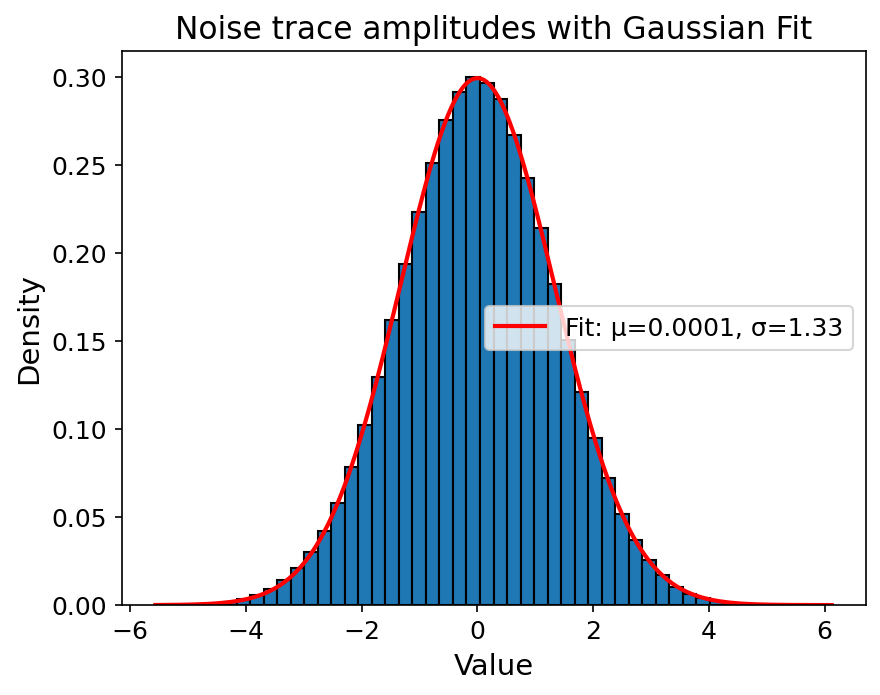

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Plot histogram
counts, bins, patches = plt.hist(amps, bins=50, edgecolor="black", density=True)  
# use density=True so area under histogram = 1 (needed for Gaussian fit)

# Bin centers for plotting
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Fit a Gaussian
mu, sigma = norm.fit(amps)  # mean and standard deviation

# Gaussian curve
x = np.linspace(min(amps), max(amps), 1000)
pdf = norm.pdf(x, mu, sigma)

# Plot Gaussian fit
plt.plot(x, pdf, "r-", linewidth=2, label=f"Fit: μ={mu:.4f}, σ={sigma:.2f}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Noise trace amplitudes with Gaussian Fit")
plt.legend()
plt.show()


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from concurrent.futures import ProcessPoolExecutor, as_completed

# Assume WORKER_OF_SUB is already constructed/imported in your environment
# from yourmodule import WORKER_OF_SUB

# --- Inputs ---
# Directory with the 2×N local PSD .npy files: row0=freq(Hz), row1=PSD(units^2/Hz)
noise_dir = "./raw_psd"
local_noise_files = [
    "Er_noise.npy",
    "Johnson_noise.npy",
    "SQUID_noise.npy",
    "TD_noise.npy",
    "total_noise.npy",
]

# External/reference PSDs you uploaded
X_RAY_PATH = "noise_psd_xray.npy"       # 2×N (freq; psd)
MMC_PATH   = "noise_psd_from_MMC.npy"   # can be 1D (psd) or 2×N

# Output dir
out_dir = os.path.join(noise_dir, "figs")
os.makedirs(out_dir, exist_ok=True)

# Optional reproducibility
# np.random.seed(1234)  # uncomment to fix the synthesized noise

# ---------- Helpers ----------
def load_freq_psd_from_npy(path):
    """
    Return (freq, psd) if file is 2×N, else (None, psd) if 1D PSD only.
    """
    arr = np.load(path, allow_pickle=False)
    if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
        f = arr[0].astype(np.float64)
        p = arr[1].astype(np.float64)
        order = np.argsort(f)
        return f[order], p[order]
    elif isinstance(arr, np.ndarray) and arr.ndim == 1:
        return None, arr.astype(np.float64)
    else:
        raise ValueError(f"{path}: unsupported shape {getattr(arr, 'shape', None)}")

def make_uniform_df(freq):
    df = np.median(np.diff(freq))
    if not np.allclose(np.diff(freq), df, rtol=1e-6, atol=1e-12):
        raise ValueError("Frequency bins are not uniformly spaced.")
    return df

def synthesize_noise_from_psd(freq, psd, df, dtype=np.float32):
    """
    Generate a real-valued time-domain noise trace from a one-sided PSD (includes DC & Nyquist).
    Ensures E{|X_k|^2} ~ PSD * df.
    """
    psd = np.maximum(psd, 0.0)
    M = len(freq)             # one-sided bins (0..Nyquist)
    N = 2 * (M - 1)           # time length for irfft
    H = np.zeros(M, dtype=np.complex128)
    # DC, Nyquist (purely real)
    H[0]  = np.random.normal(0.0, np.sqrt(psd[0]  * df))
    H[-1] = np.random.normal(0.0, np.sqrt(psd[-1] * df))
    # Interior complex bins
    if M > 2:
        std = np.sqrt(0.5 * psd[1:-1] * df)
        H[1:-1] = np.random.normal(0.0, std) + 1j * np.random.normal(0.0, std)
    x = np.fft.irfft(H, n=N)
    return x.astype(dtype, copy=False)

def fit_and_plot(amps, title, out_png):
    plt.figure()
    plt.hist(amps, bins=50, edgecolor="black", density=True, alpha=0.6, label="Histogram")
    mu, sigma = norm.fit(amps)
    x = np.linspace(np.min(amps), np.max(amps), 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), "r-", linewidth=2, label=f"Fit: μ={mu:.4f}, σ={sigma:.4f}")
    plt.xlabel("Amplitude"); plt.ylabel("Density"); plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.close()
    return mu, sigma

# ---------- Load reference frequency (from X-ray) for any 1D PSDs ----------
freq_ref, psd_ref = load_freq_psd_from_npy(X_RAY_PATH)
if freq_ref is None:
    raise RuntimeError("X-ray PSD must provide a frequency axis (2×N).")

if freq_ref[0] > 1e-12:
    raise ValueError(f"X-ray freq does not start at DC=0. Got {freq_ref[0]}")
df_ref = make_uniform_df(freq_ref)

# ---------- Build the workload (label, path, is_1d) ----------
work = []
# Local 2×N files
for fname in local_noise_files:
    work.append((os.path.splitext(fname)[0], os.path.join(noise_dir, fname), False))
# X-ray (2×N)
work.append(("Xray", X_RAY_PATH, False))
# MMC (could be 1D or 2×N)
mmc_freq, _mmc_psd = load_freq_psd_from_npy(MMC_PATH)
work.append(("MMC", MMC_PATH, mmc_freq is None))

def process_one(label, path, is_1d):
    try:
        f, p = load_freq_psd_from_npy(path)
        if is_1d:
            # borrow reference freq from X-ray
            if p.size != freq_ref.size:
                raise ValueError(f"{label}: 1D PSD length {p.size} != X-ray freq length {freq_ref.size}")
            f = freq_ref.copy()
        # common checks
        if f[0] > 1e-12:
            raise ValueError(f"{label}: first frequency is not DC=0. Got {f[0]}")
        df = make_uniform_df(f)
        # synthesize time-domain noise
        noise_trace32 = synthesize_noise_from_psd(f, p, df, dtype=np.float32)
        # sliding fit
        amps, _ = WORKER_OF_SUB.sliding_fit(noise_trace32, hop=1, reanchor_every=None, chisq_mode="none")
        # plot + gaussian fit
        out_png = os.path.join(out_dir, f"{label}_amps_hist.png")
        mu, sigma = fit_and_plot(amps, title=f"{label}: Noise trace amplitudes with Gaussian Fit", out_png=out_png)
        return {"label": label, "N_time": noise_trace32.size, "N_freq": f.size, "df": df,
                "mu": float(mu), "sigma": float(sigma), "plot": out_png}
    except Exception as e:
        return {"label": label, "error": str(e)}

def main():
    results = []
    with ProcessPoolExecutor() as ex:
        futs = {ex.submit(process_one, *item): item[0] for item in work}
        for fut in as_completed(futs):
            res = fut.result()
            results.append(res)
            if "error" in res:
                print(f"[{res['label']}] ERROR: {res['error']}")
            else:
                print(f"[{res['label']}] μ={res['mu']:.6g}, σ={res['sigma']:.6g}, "
                      f"N_time={res['N_time']}, N_freq={res['N_freq']}, df={res['df']:.6g}")
                print(f"  → plot: {res['plot']}")
    # Summary
    ok = [r for r in results if "error" not in r]
    if ok:
        mus = np.array([r["mu"] for r in ok], float)
        sigmas = np.array([r["sigma"] for r in ok], float)
        print("\nSummary:")
        for r in ok:
            print(f"  {r['label']:<10} μ={r['mu']:.6g}, σ={r['sigma']:.6g}")
        print(f"\nOverall mean(μ)={mus.mean():.6g}, mean(σ)={sigmas.mean():.6g}")

if __name__ == "__main__":
    main()


[Johnson_noise] ERROR: Frequency bins are not uniformly spaced.
[Er_noise] ERROR: Frequency bins are not uniformly spaced.
[total_noise] ERROR: Frequency bins are not uniformly spaced.
[SQUID_noise] ERROR: Frequency bins are not uniformly spaced.
[TD_noise] ERROR: Frequency bins are not uniformly spaced.
[MMC] ERROR: name 'WORKER_OF_SUB' is not defined
[Xray] ERROR: name 'WORKER_OF_SUB' is not defined


In [4]:
import os
import numpy as np

noise_dir = "./raw_psd"
local_noise_files = [
    "Er_noise.npy",
    "Johnson_noise.npy",
    "SQUID_noise.npy",
    "TD_noise.npy",
    "total_noise.npy",
]

# External/reference PSDs
X_RAY_PATH = "noise_psd_xray.npy"       # 2×N (freq; psd)
MMC_PATH   = "noise_psd_from_MMC.npy"   # 1D or 2×N

def summarize_freq(label, freq):
    freq = np.asarray(freq, dtype=float)
    N = freq.size
    df = np.diff(freq)
    df_med = float(np.median(df)) if N > 1 else float("nan")
    uniform = bool(np.allclose(df, df_med, rtol=1e-6, atol=1e-12)) if N > 1 else False
    increasing = bool(np.all(np.diff(freq) > 0)) if N > 1 else False
    print(f"{label}:")
    print(f"  bins: N={N}, f_min={freq[0]:.6g} Hz, f_max={freq[-1]:.6g} Hz")
    print(f"  df_median={df_med:.6g} Hz, uniform={uniform}, strictly_increasing={increasing}")
    print(f"  starts_at_DC={np.isclose(freq[0], 0.0, atol=1e-12)}")
    print(f"  first 5: {freq[:5]}")
    print(f"  last  5: {freq[-5:]}\n")

def load_freq_psd(path):
    arr = np.load(path, allow_pickle=False)
    if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2:
        f = arr[0].astype(float); p = arr[1].astype(float)
        order = np.argsort(f)
        return f[order], p[order]
    elif isinstance(arr, np.ndarray) and arr.ndim == 1:
        return None, arr.astype(float)
    else:
        raise ValueError(f"{path}: unsupported array shape {getattr(arr, 'shape', None)}")

# Load X-ray first (reference grid)
f_x, p_x = load_freq_psd(X_RAY_PATH)
if f_x is None:
    raise RuntimeError("X-ray PSD must include a frequency axis (2×N).")

# Check locals
for fname in local_noise_files:
    path = os.path.join(noise_dir, fname)
    if not os.path.exists(path):
        print(f"{fname}: not found at {path}\n"); continue
    try:
        f, p = load_freq_psd(path)
        if f is None:
            # 1D PSD—try to infer from X-ray if length matches
            if p.size == f_x.size:
                summarize_freq(f"{fname} (inferred from X-ray)", f_x)
            else:
                print(f"{fname}: 1D PSD with length {p.size} — can't infer freq (X-ray has {f_x.size}).\n")
        else:
            summarize_freq(fname, f)
    except Exception as e:
        print(f"{fname}: ERROR: {e}\n")

# Check X-ray and MMC
print("Reference (X-ray):")
summarize_freq("noise_psd_xray.npy", f_x)

try:
    f_m, p_m = load_freq_psd(MMC_PATH)
    if f_m is None:
        if p_m.size == f_x.size:
            summarize_freq("noise_psd_from_MMC.npy (inferred from X-ray)", f_x)
        else:
            print(f"noise_psd_from_MMC.npy: 1D PSD length {p_m.size} — can't infer freq (X-ray has {f_x.size}).\n")
    else:
        summarize_freq("noise_psd_from_MMC.npy", f_m)
except Exception as e:
    print(f"noise_psd_from_MMC.npy: ERROR: {e}\n")


Er_noise.npy:
  bins: N=16385, f_min=0 Hz, f_max=3e+07 Hz
  df_median=5.75293 Hz, uniform=False, strictly_increasing=True
  starts_at_DC=True
  first 5: [0.         1.         1.00105144 1.00210399 1.00315764]
  last  5: [29874158.0450101  29905568.95893975 29937012.89959145 29968489.90169078
 30000000.00000001]

Johnson_noise.npy:
  bins: N=16385, f_min=0 Hz, f_max=3e+07 Hz
  df_median=5.75293 Hz, uniform=False, strictly_increasing=True
  starts_at_DC=True
  first 5: [0.         1.         1.00105144 1.00210399 1.00315764]
  last  5: [29874158.0450101  29905568.95893975 29937012.89959145 29968489.90169078
 30000000.00000001]

SQUID_noise.npy:
  bins: N=16385, f_min=0 Hz, f_max=3e+07 Hz
  df_median=5.75293 Hz, uniform=False, strictly_increasing=True
  starts_at_DC=True
  first 5: [0.         1.         1.00105144 1.00210399 1.00315764]
  last  5: [29874158.0450101  29905568.95893975 29937012.89959145 29968489.90169078
 30000000.00000001]

TD_noise.npy:
  bins: N=16385, f_min=0 Hz, f_ma

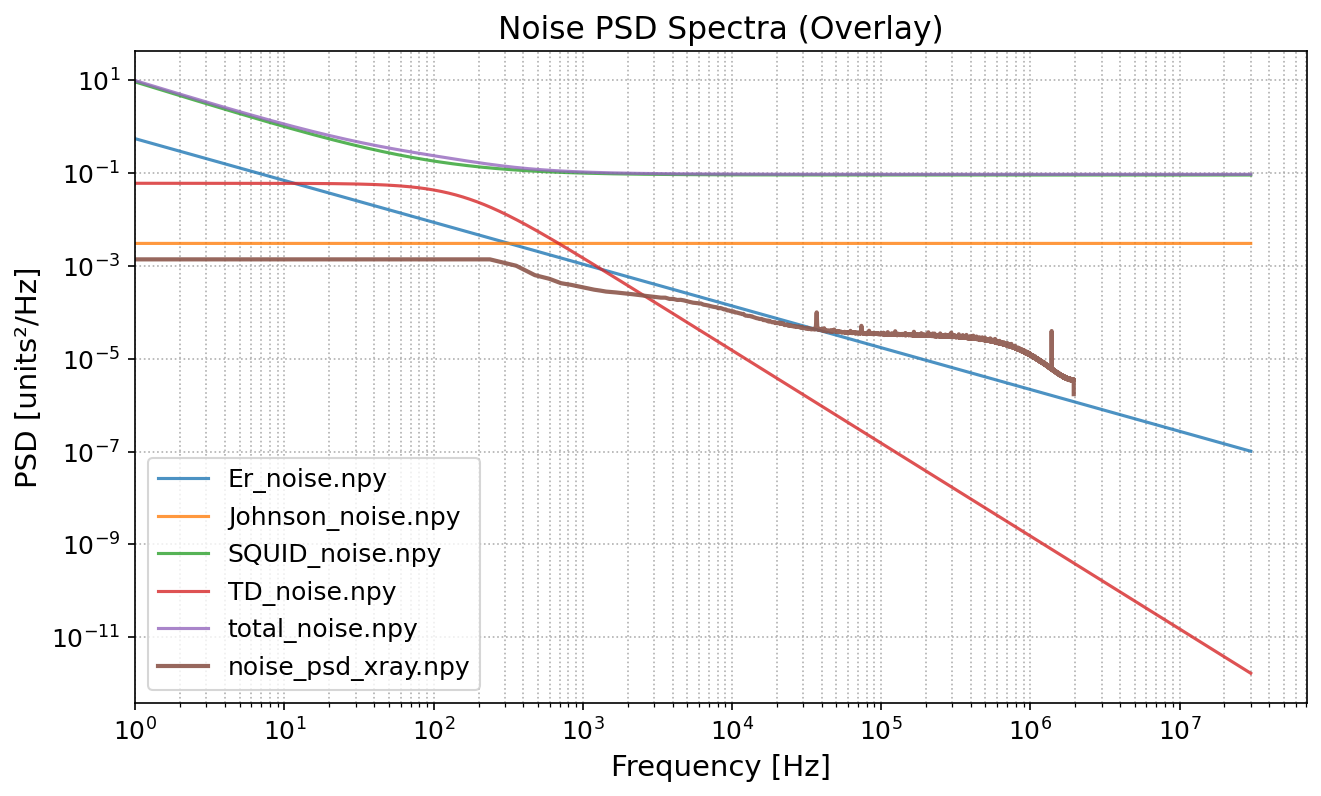

/tmp/ipykernel_3052847/2063445650.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


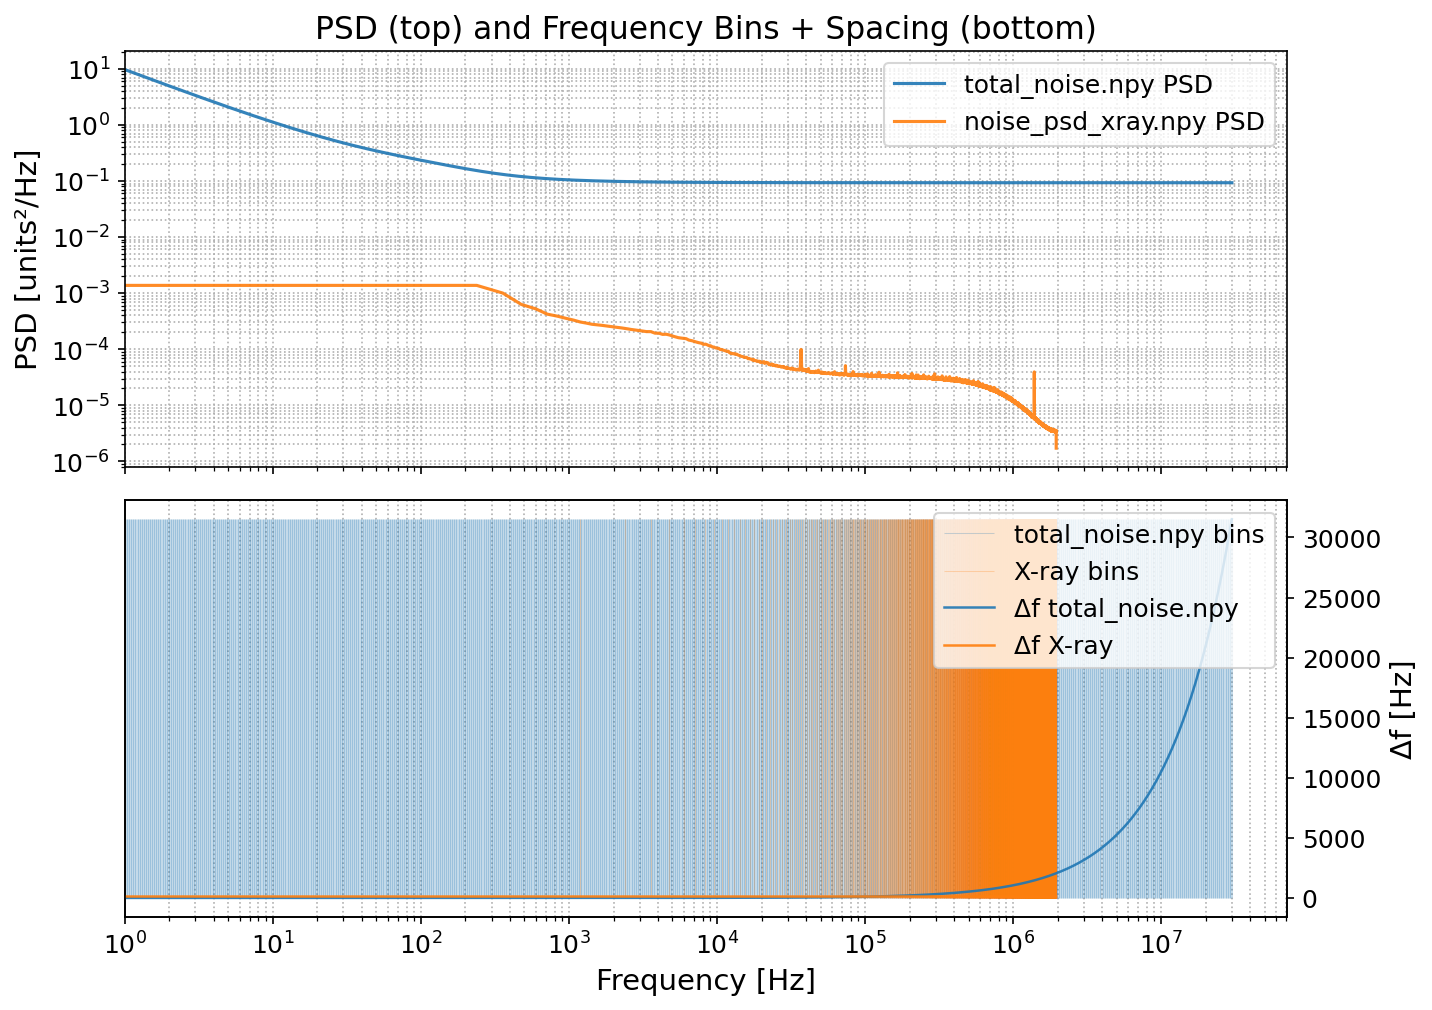


Er_noise.npy: frequency bins (from 1 Hz; total 16384 bins)
(showing every 100th bin) -> [1.00000000e+00 1.11080931e+00 1.23389733e+00 1.37062464e+00 1.52250262e+00 1.69121009e+00 1.87861191e+00 2.08677961e+00 2.31801422e+00
 2.57487178e+00 2.86019156e+00 3.17712742e+00 3.52918272e+00 3.92024903e+00 4.35464913e+00 4.83718481e+00 5.37318993e+00 5.96858942e+00
 6.62996470e+00 7.36462654e+00 8.18069574e+00 9.08719301e+00 1.00941386e+01 1.12126632e+01 1.24551307e+01 1.38352751e+01 1.53683525e+01
 1.70713090e+01 1.89629691e+01 2.10642426e+01 2.33983569e+01 2.59911127e+01 2.88711701e+01 3.20703646e+01 3.56240596e+01 3.95715372e+01
 4.39564320e+01 4.88272140e+01 5.42377240e+01 6.02477689e+01 6.69237828e+01 7.43395611e+01 8.25770768e+01 9.17273859e+01 1.01891634e+02
 1.13182176e+02 1.25723816e+02 1.39655185e+02 1.55130280e+02 1.72320160e+02 1.91414838e+02 2.12625385e+02 2.36186258e+02 2.62357895e+02
 2.91429593e+02 3.23722705e+02 3.59594196e+02 3.99440582e+02 4.43702318e+02 4.92868667e+02 5.47

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- inputs ---
noise_dir = "./raw_psd"
local_noise_files = [
    "Er_noise.npy",
    "Johnson_noise.npy",
    "SQUID_noise.npy",
    "TD_noise.npy",
    "total_noise.npy",
]
X_RAY_PATH = "noise_psd_xray.npy"  # 2×N [freq; psd]

# pick ONE representative local file to show bins clearly
REP_LOCAL = "total_noise.npy"

# printing controls
PRINT_ALL = False   # set True to dump all bin values
PRINT_STRIDE = 100  # when PRINT_ALL=False, print every Nth bin (starting at ≥ 1 Hz)

def load_freq_psd_npy(path):
    arr = np.load(path, allow_pickle=False)
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[0] == 2):
        raise ValueError(f"{path} must be 2×N [freq; psd], got {getattr(arr, 'shape', None)}.")
    f = arr[0].astype(float); p = arr[1].astype(float)
    order = np.argsort(f)
    return f[order], p[order]

def compute_df(f):
    return np.diff(f)

def print_bins(label, f, start_at=1.0, stride=100, print_all=False):
    idx0 = np.searchsorted(f, start_at, side="left")
    f_view = f[idx0:]
    print(f"\n{label}: frequency bins (from {start_at:g} Hz; total {f_view.size} bins)")
    if print_all:
        np.set_printoptions(suppress=False, threshold=np.inf, linewidth=140)
        print(f_view)
    else:
        # sample every 'stride' bin to keep output readable
        sample = f_view[::stride]
        np.set_printoptions(suppress=False, threshold=np.inf, linewidth=140)
        print(f"(showing every {stride}th bin) -> {sample}")
        # also show the last ~10 bins for context
        tail = f_view[-10:]
        print("last 10 bins:", tail)

# --- load datasets ---
local_data = []
for fn in local_noise_files:
    f, p = load_freq_psd_npy(os.path.join(noise_dir, fn))
    local_data.append((fn, f, p))

f_x, p_x = load_freq_psd_npy(X_RAY_PATH)

# --- figure 1: PSD spectra overlay ---
plt.figure(figsize=(9, 5.5))
for (name, f, p) in local_data:
    plt.loglog(f, p, label=name, alpha=0.8)
plt.loglog(f_x, p_x, label="noise_psd_xray.npy", linewidth=2.0, alpha=0.9)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [units²/Hz]")
plt.title("Noise PSD Spectra (Overlay)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.xlim(left=1.0)  # start x-axis at 10^0 = 1 Hz
plt.tight_layout()
plt.show()

# --- figure 2: bin locations + Δf (rep local vs X-ray) ---
# pick representative local
f_loc, p_loc = None, None
for (name, f, p) in local_data:
    if name == REP_LOCAL:
        f_loc, p_loc = f, p
        break
if f_loc is None:
    f_loc, p_loc = local_data[0][1], local_data[0][2]
    REP_LOCAL = local_data[0][0]

df_loc = compute_df(f_loc)
df_x   = compute_df(f_x)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True, gridspec_kw={"hspace": 0.08})

# top: PSDs
ax_top.loglog(f_loc, p_loc, label=f"{REP_LOCAL} PSD", alpha=0.9)
ax_top.loglog(f_x,   p_x,   label="noise_psd_xray.npy PSD", alpha=0.9)
ax_top.set_ylabel("PSD [units²/Hz]")
ax_top.set_title("PSD (top) and Frequency Bins + Spacing (bottom)")
ax_top.grid(True, which="both", ls=":")
ax_top.legend()

# bottom: bin ticks + Δf
y0, y1 = 0.0, 1.0
def vlines_bins(ax, f, color, label=None, step=1):
    ax.vlines(f[::step], y0, y1, color=color, alpha=0.25, lw=0.5, label=label)

stride_loc = max(1, len(f_loc)//1500)
stride_x   = max(1, len(f_x)//1500)

vlines_bins(ax_bot, f_loc, color="C0", label=f"{REP_LOCAL} bins", step=stride_loc)
vlines_bins(ax_bot, f_x,   color="C1", label="X-ray bins", step=stride_x)

ax2 = ax_bot.twinx()
ax2.semilogx(f_loc[:-1], df_loc, color="C0", alpha=0.9, lw=1.2, label=f"Δf {REP_LOCAL}")
ax2.semilogx(f_x[:-1],   df_x,   color="C1", alpha=0.9, lw=1.2, label="Δf X-ray")

ax_bot.set_yticks([])
ax_bot.set_xlabel("Frequency [Hz]")
ax_bot.grid(True, which="both", axis="x", ls=":")
ax_bot.set_xlim(left=1.0)  # start x-axis at 10^0 = 1 Hz

# combine legends
lines1, labels1 = ax_bot.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax2.set_ylabel("Δf [Hz]")
plt.tight_layout()
plt.show()

# --- PRINT the frequency bins (from 1 Hz upward) ---
for (name, f, _p) in local_data:
    print_bins(name, f, start_at=1.0, stride=PRINT_STRIDE, print_all=PRINT_ALL)

print_bins("noise_psd_xray.npy", f_x, start_at=1.0, stride=PRINT_STRIDE, print_all=PRINT_ALL)


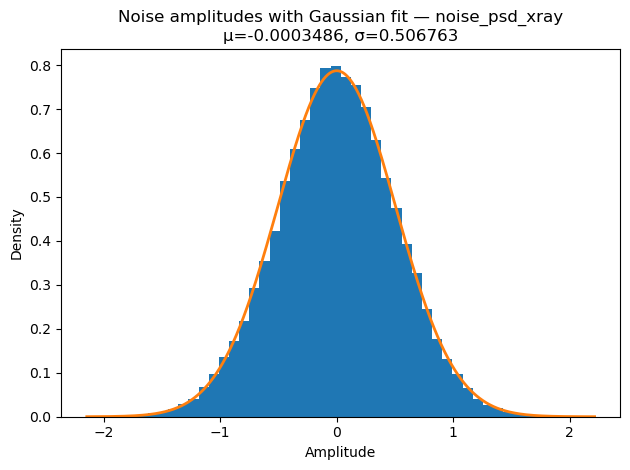

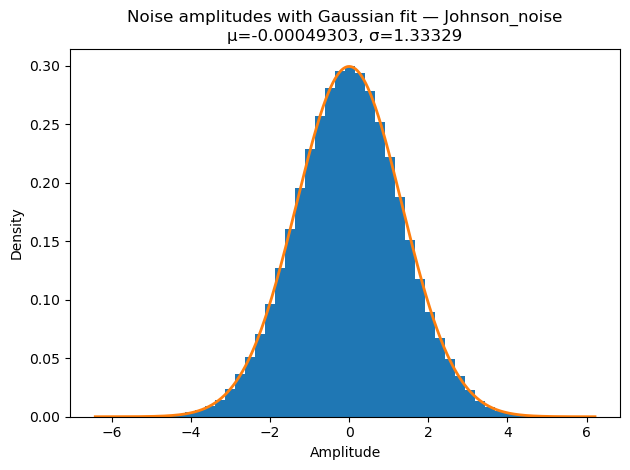

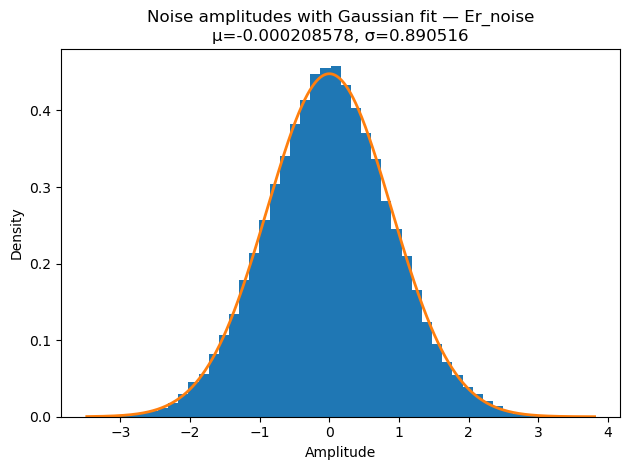

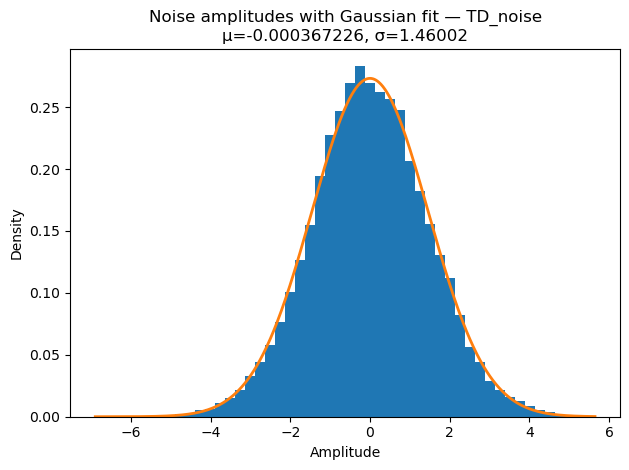

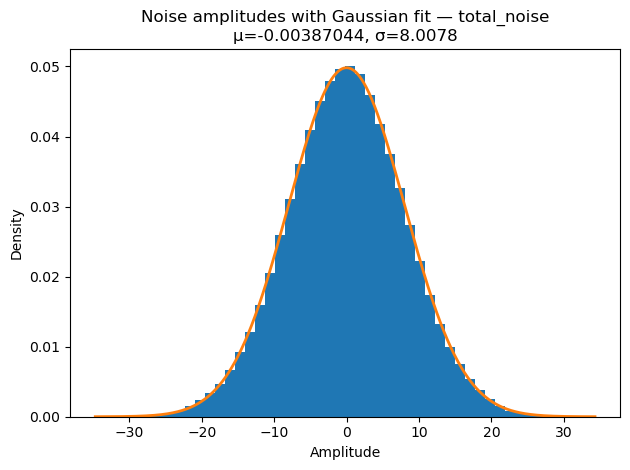

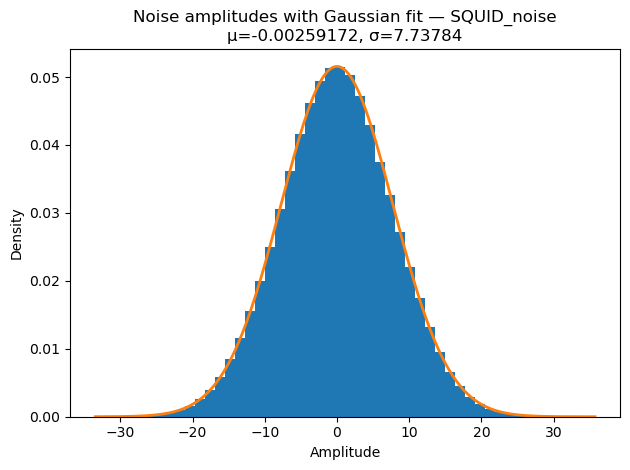


=== Summary (per noise PSD) ===
PSD                       mu         sigma  n_amps  (key)
noise_psd_xray    -0.0003486      0.506763  4967233  (noise_type)
Johnson_noise    -0.00049303       1.33329  4967233  (noise_type)
Er_noise        -0.000208578      0.890516  4967233  (noise_type)
TD_noise        -0.000367226       1.46002  4967233  (noise_type)
total_noise      -0.00387044        8.0078  4967233  (noise_type)
SQUID_noise      -0.00259172       7.73784  4967233  (noise_type)


In [2]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter

# ---------- config helpers ----------
def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as f:
        return yaml.safe_load(f)

def set_noise_psd_path(config: dict, psd_path: str):
    """
    Update the config to point to the given PSD path.
    Tries a few common keys; creates 'noise_type' if nothing matches.
    """
    # Try nested structure first
    if isinstance(config.get("noise"), dict) and "psd_path" in config["noise"]:
        config["noise"]["psd_path"] = psd_path
        return config, "noise.psd_path"
    # Try flat keys
    if "noise_psd_path" in config:
        config["noise_psd_path"] = psd_path
        return config, "noise_psd_path"
    if "noise_type" in config:
        config["noise_type"] = psd_path
        return config, "noise_type"
    # Fallback: create a simple key
    config["noise_type"] = psd_path
    return config, "noise_type"

# ---------- user inputs ----------
yaml_path = "/home/dwong/DELight_mtr/trigger_study/wk22/standardized_flow/calibration_config.yaml"
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
OF_psd = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
fs = 3_906_250  # Hz
trace_len = 5_000_000  # samples for noise generation

psd_paths = [
    "/ceph/dwong/delight_conf/new/noise_psd_xray.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/Johnson_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/Er_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/TD_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/total_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk22/raw_psd/SQUID_noise.npy",
]

# ---------- load base config ----------
base_config = read_yaml_to_dict(yaml_path)

# ---------- run loop ----------
summary = []  # list of dicts with name, mu, sigma, key_used
for psd_path in psd_paths:
    # 1) update config in-memory
    config = yaml.safe_load(yaml.dump(base_config))  # deep copy via yaml round-trip
    config, key_used = set_noise_psd_path(config, psd_path)

    # 2) regenerate noise with this PSD
    lts = LongTraceSimulator(config)
    ng = NoiseGenerator(config)
    noise_trace = ng.generate_noise(trace_len).astype(np.float32)

    # 3) build OptimumFilter with the same PSD
    noise_psd = np.load(OF_psd)
    worker = OptimumFilter(sub_template, noise_psd, fs)

    # 4) slide to get amplitudes
    amps, _ = worker.sliding_fit(noise_trace, hop=1, reanchor_every=None, chisq_mode="none")

    # 5) fit Gaussian to amplitudes
    mu, sigma = norm.fit(amps)

    # 6) histogram + Gaussian curve (one chart per config, no explicit colors/styles)
    counts, bins, patches = plt.hist(amps, bins=50, density=True)
    x = np.linspace(float(np.min(amps)), float(np.max(amps)), 1000)
    pdf = norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, linewidth=2)
    fname = os.path.splitext(os.path.basename(psd_path))[0]
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title(f"Noise amplitudes with Gaussian fit — {fname}\nμ={mu:.6g}, σ={sigma:.6g}")
    plt.tight_layout()
    plt.show()

    # 7) collect summary
    summary.append({
        "psd_name": fname,
        "psd_path": psd_path,
        "config_key": key_used,
        "mu": float(mu),
        "sigma": float(sigma),
        "n_amps": int(len(amps)),
    })

# ---------- print summary ----------
print("\n=== Summary (per noise PSD) ===")
w_name = max(len(s["psd_name"]) for s in summary)
w_sigma = 12
w_mu = 12
print(f"{'PSD':{w_name}}  {'mu':>{w_mu}}  {'sigma':>{w_sigma}}  n_amps  (key)")
for s in summary:
    print(f"{s['psd_name']:{w_name}}  {s['mu']:>{w_mu}.6g}  {s['sigma']:>{w_sigma}.6g}  {s['n_amps']:>6d}  ({s['config_key']})")


In [2]:
import numpy as np
import os

# Where your PSDs live (2×N: [freq; psd])
noise_dir = "./raw_psd"
files = {
    "noise_psd_xray": os.path.join(noise_dir, "noise_psd_xray.npy"),
    "Johnson_noise":  os.path.join(noise_dir, "Johnson_noise.npy"),
    "Er_noise":       os.path.join(noise_dir, "Er_noise.npy"),
    "TD_noise":       os.path.join(noise_dir, "TD_noise.npy"),
    "total_noise":    os.path.join(noise_dir, "total_noise.npy"),
    "SQUID_noise":    os.path.join(noise_dir, "SQUID_noise.npy"),
}

# Measured amp sigmas from your summary
sigma_meas = {
    "noise_psd_xray": 0.506763,
    "Johnson_noise":  1.33329,
    "Er_noise":       0.890516,
    "TD_noise":       1.46002,
    "total_noise":    8.0078,
    "SQUID_noise":    7.73784,
}

# Choose a target sigma (match to X-ray by default)
sigma_target = sigma_meas["noise_psd_xray"]

def rescale_psd_2xN(path_in, path_out, c):
    freq, psd = np.load(path_in, allow_pickle=False)
    psd_new = np.maximum(psd * c, 0.0)
    np.save(path_out, np.vstack([freq, psd_new]))

print("=== Scaling to target sigma =", sigma_target, "===")
for name, path in files.items():
    s = sigma_meas[name]
    c = (sigma_target / s) ** 2  # PSD scale factor
    out = os.path.splitext(path)[0] + "_norm.npy"
    rescale_psd_2xN(path, out, c)
    print(f"{name:<15}  sigma={s:.6g}  c={(c):.6g}  -> {os.path.basename(out)}")


=== Scaling to target sigma = 0.506763 ===
noise_psd_xray   sigma=0.506763  c=1  -> noise_psd_xray_norm.npy
Johnson_noise    sigma=1.33329  c=0.144464  -> Johnson_noise_norm.npy
Er_noise         sigma=0.890516  c=0.323837  -> Er_noise_norm.npy
TD_noise         sigma=1.46002  c=0.120474  -> TD_noise_norm.npy
total_noise      sigma=8.0078  c=0.00400482  -> total_noise_norm.npy
SQUID_noise      sigma=7.73784  c=0.00428914  -> SQUID_noise_norm.npy
